**Анализ тональности обращений граждан**

# Введение
В данном исследовании была разработана и протестирована система автоматического определения эмоциональной тональности текстов обращений граждан в органы местного управления. Решение основано на дообучении предварительно обученной языковой модели с применением современных методов обработки естественного языка.

1. Источники: Обучающий датасет: [Russian Sentiment Dataset](https://www.kaggle.com/datasets/mar1mba/russian-sentiment-dataset) с платформы Kaggle (290,458 текстовых отзывов о товарах и услугах на русском языке). Базовая модель: [ai-forever/ruBert-base](https://huggingface.co/ai-forever/ruBert-base) (104M параметров).

2. Практическая значимость
Разработанное решение может быть применено для:
 - Автоматической категоризации обращений граждан по тональности
 - Мониторинга удовлетворённости услугами органов власти
 - Выявления проблемных тем через анализ частоты негативных обращений
 - Оценки эффективности мероприятий по динамике тональности обращений

3. Архитектура решения:
Базовая модель: ai-forever/ruBert-base (104M параметров), Добавлен классификационный слой поверх предобученной BERT-модели, использовалось Fine-tuning для задачи классификации с тремя классами (нейтральный/положительный/отрицательный)

4. Техническая реализация: 
- Фреймворк: PyTorch + Transformers
- Гиперпараметры:
  - Learning rate: 5e-05
  - Batch size: 16
  - Количество эпох: 3
  - Максимальная длина текста: 256 токенов
- Аппаратное обеспечение: Использование GPU при доступности (CUDA)

5. Стратегии обработки длинных текстов
В ходе исследования были реализованы и протестированы три стратегии обработки текстов, превышающих максимальную длину модели:
 - Truncate (обрезание) - стандартный подход, обрезающий текст до 256 токенов
 - Average (усреднение) - разделение текста на части с последующим усреднением вероятностей
 - Summary (суммаризация) - анализ ключевых сегментов текста (начало, середина, конец)

6. В качестве тестов использовалось 22 текста, имитирующих обращения граждан в органы власти, с длинами текстов от кратких 20-50 до развернутых (200-300 слов)

7. Метрики качества
 - Accuracy - общая точность классификации
 - Precision/Recall/F1-score - по каждому классу тональности
 - Confidence - уверенность модели в предсказаниях

8. Процедура валидации
 - Разделение исходного датасета на обучающую (70%), валидационную (15%) и тестовую (15%) выборки
 - Стратифицированное разделение для сохранения баланса классов
 - Кросс-валидация на синтезированных обращениях
 - Сравнение различных стратегий обработки длинных текстов





## Библиотеки

In [ ]:
import kagglehub # Для загрузки датасетов с Kaggle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import getpass
from huggingface_hub import InferenceClient # Клиент для Hugging Face API
from tqdm.auto import tqdm # Для прогресс-баров
# Дополнительные импорты
import torch # Основная библиотека для глубокого обучения
from torch.utils.data import Dataset, DataLoader  # Для создания датасетов и их загрузки
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,    
    get_linear_schedule_with_warmup,
    AutoModelForMaskedLM,
    pipeline
) # Библиотека для работы с трансформерами
from torch.optim import AdamW # Оптимизатор
from collections import Counter # Для подсчета элементов
from sklearn.model_selection import train_test_split # Для разделения данных
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # Для оценки модели
import warnings
warnings.filterwarnings('ignore')

## Анализ базы данных и загрузка моделей для дообучения

In [37]:
# Загружаем датасет с русскими отзывами для анализа тональности
path = kagglehub.dataset_download("mar1mba/russian-sentiment-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\V\.cache\kagglehub\datasets\mar1mba\russian-sentiment-dataset\versions\2


In [38]:
# Посмотрим какие файлы есть в директории
print("Files in directory:")
for file in os.listdir(path):
    print(f" - {file}")

Files in directory:
 - sentiment_dataset.csv


In [39]:
# Загружаем датасет в DataFrame
df = pd.read_csv(os.path.join(path, 'sentiment_dataset.csv'))

In [40]:
# ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ
print(f"Размер датасета: {df.shape}")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print("\nИнформация о столбцах:")
print(df.info())
print("\nПервые 5 строк датасета:")
print(df.head())
print("\nОсновные статистики:")
print(df.describe(include='all'))

Размер датасета: (290458, 3)
Количество строк: 290458
Количество столбцов: 3

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290458 entries, 0 to 290457
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    290458 non-null  object
 1   label   290458 non-null  int64 
 2   src     290458 non-null  object
dtypes: int64(1), object(2)
memory usage: 6.6+ MB
None

Первые 5 строк датасета:
                                                text  label        src
0  Пальто красивое, но пришло с дырой в молнии. П...      0  rureviews
1  Очень долго шел заказ,ждала к новому году,приш...      0  rureviews
2  Могу сказать одно, брюки нормальные, НО они бы...      0  rureviews
3  Доставка быстрая, меньше месяца. Заказывали ра...      0  rureviews
4  Мне не очень  понравилось это платье. Размер  ...      0  rureviews

Основные статистики:
                     text          label        src
count              2904

In [41]:
# Проверяем наличие пропущенных значений
df.isnull().sum()

text     0
label    0
src      0
dtype: int64

In [42]:
# Анализируем распределение меток (классов)
label_distribution = df['label'].value_counts().sort_index()
label_names = {0: 'Neutral', 1: 'Positive', 2: 'Negative'}

Распределение меток:
Label 0 (Neutral): 96589 записей (33.25%)
Label 1 (Positive): 96877 записей (33.35%)
Label 2 (Negative): 96992 записей (33.39%)


Text(0, 0.5, 'Количество отзывов')

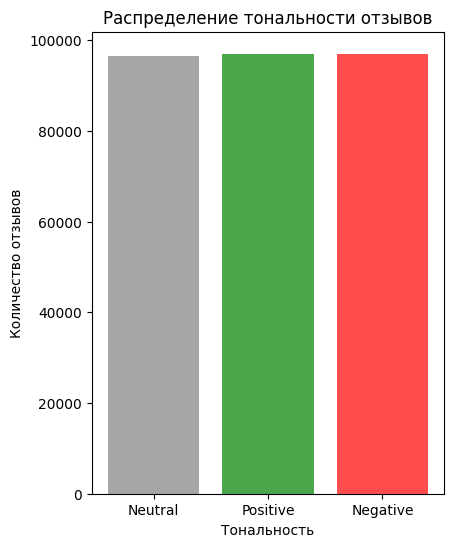

In [43]:
print("Распределение меток:")
for label, count in label_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"Label {label} ({label_names[label]}): {count} записей ({percentage:.2f}%)")

# Визуализация распределения меток
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
bars = plt.bar(label_names.values(), label_distribution.values, 
               color=['gray', 'green', 'red'], alpha=0.7)
plt.title('Распределение тональности отзывов')
plt.xlabel('Тональность')
plt.ylabel('Количество отзывов')

- База данных хорошо сбалансирована изначально

In [44]:
# Удаляем ненужную колонку
df = df.drop('src', axis=1)

In [45]:
# Инициализируем pipeline для задачи fill-mask (проверка работы модели)
pipe = pipeline("fill-mask", model="ai-forever/ruBert-base")

Some weights of the model checkpoint at ai-forever/ruBert-base were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


In [46]:
# Загружаем токенизатор и модель для дообучения
tokenizer = AutoTokenizer.from_pretrained("ai-forever/ruBert-base")
model = AutoModelForMaskedLM.from_pretrained("ai-forever/ruBert-base")

Some weights of the model checkpoint at ai-forever/ruBert-base were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [48]:
# Настраиваем доступ к Hugging Face API
hf_token = getpass.getpass("Введите ваш HF_TOKEN: ").strip()

In [ ]:
os.environ["HF_TOKEN"] = hf_token

In [ ]:
client = InferenceClient(
    provider="auto",
    api_key=os.environ["HF_TOKEN"],
)
# Тестируем подключение к Hugging Face
result = client.fill_mask(
    "The answer to the universe is [MASK].",
    model="ai-forever/ruBert-base",
)


In [ ]:
# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


## Предобработка данных

In [ ]:
# Предобработка данных
def preprocess_text(text):
    if isinstance(text, str):
        # Удаление лишних пробелов
        text = re.sub(r'\s+', ' ', text)
        # Очистка от специальных символов 
        text = re.sub(r'[^\w\s\.\,\!\?]', '', text)
        return text.strip()
    return ""

In [ ]:
# Применяем предобработку
df['cleaned_text'] = df['text'].apply(preprocess_text)

# Проверяем результат
print("Примеры текстов после очистки:")
for i in range(3):
    print(f"Оригинал: {df['text'].iloc[i][:100]}...")
    print(f"Очищенный: {df['cleaned_text'].iloc[i][:100]}...")
    print("-" * 50)

Примеры текстов после очистки:
Оригинал: Пальто красивое, но пришло с дырой в молнии. Просила выслать такую же, но продавец настаивал на откр...
Очищенный: Пальто красивое, но пришло с дырой в молнии. Просила выслать такую же, но продавец настаивал на откр...
--------------------------------------------------
Оригинал: Очень долго шел заказ,ждала к новому году,пришел, когда уже не нужен,разочарована....
Очищенный: Очень долго шел заказ,ждала к новому году,пришел, когда уже не нужен,разочарована....
--------------------------------------------------
Оригинал: Могу сказать одно, брюки нормальные, НО они были порваны, и малы, заказывала второй раз, в этот раз ...
Очищенный: Могу сказать одно, брюки нормальные, НО они были порваны, и малы, заказывала второй раз, в этот раз ...
--------------------------------------------------


## Обучение модели

In [ ]:
# Гиперпараметры
learning_rate = 5e-05 # Скорость обучения
train_batch_size = 16 # Размер батча для обучения
eval_batch_size = 16  # Размер батча для валидации и тестирования
seed = 42 # Seed для воспроизводимости
num_epochs = 3 # Количество эпох обучения
max_length = 256 # Максимальная длина текста


In [ ]:
# Устанавливаем seed для воспроизводимости
torch.manual_seed(seed)
np.random.seed(seed)

In [ ]:
# Создаем датасет для PyTorch
"""
Кастомный класс датасета для PyTorch.
Преобразует тексты и метки в формат, подходящий для модели BERT.
"""
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
         # Токенизация текста с паддингом и обрезкой
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(), # Индексы токенов
            'attention_mask': encoding['attention_mask'].flatten(), # Маска внимания
            'labels': torch.tensor(label, dtype=torch.long) # Метки класса
        }

# Разделение данных
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=seed, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=seed, stratify=temp_df['label'])

print(f"Размер тренировочного набора: {len(train_df)}")
print(f"Размер валидационного набора: {len(val_df)}")
print(f"Размер тестового набора: {len(test_df)}")

Размер тренировочного набора: 203320
Размер валидационного набора: 43569
Размер тестового набора: 43569


In [ ]:
# Инициализация токенизатора и модели
model_name = "ai-forever/ruBert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Создаем модель для классификации с 3 классами
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label={0: "Neutral", 1: "Positive", 2: "Negative"},
    label2id={"Neutral": 0, "Positive": 1, "Negative": 2}
)
model.to(device) # Перемещаем модель на GPU

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(120138, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [ ]:
# Создаем DataLoader'ы
train_dataset = ReviewDataset(train_df['cleaned_text'].values, train_df['label'].values, tokenizer, max_length)
val_dataset = ReviewDataset(val_df['cleaned_text'].values, val_df['label'].values, tokenizer, max_length)
test_dataset = ReviewDataset(test_df['cleaned_text'].values, test_df['label'].values, tokenizer, max_length)

train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=eval_batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=eval_batch_size, shuffle=False)

# Настройка оптимизатора 
optimizer = AdamW(
    model.parameters(),
    lr=learning_rate,
    betas=(0.9, 0.999),
    eps=1e-08,
    weight_decay=0.01
)

In [ ]:
# Настройка планировщика обучения с линейным прогревом
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [ ]:
# Функция для вычисления точности
def flat_accuracy(preds, labels):
    """
    preds: массив с предсказаниями (логиты или предсказанные классы)
    labels: истинные метки
    """
    # Если preds уже содержит предсказанные классы (одномерный массив)
    if preds.ndim == 1: 
        pred_flat = preds
    else:
        # Если preds содержит логиты (двумерный массив)
        pred_flat = np.argmax(preds, axis=1).flatten()
    
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [ ]:
# Функция для обучения
def train_epoch(model, data_loader, optimizer, device, scheduler):
    model.train()
    total_loss = 0
    all_predictions = []
    all_true_labels = []
    
    progress_bar = tqdm(data_loader, desc="Training")
    for batch in progress_bar:
        optimizer.zero_grad()  # Обнуляем градиенты
        
        # Перемещаем данные на нужное устройство
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Прямой проход
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        
        # Обратный проход
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Клиппинг градиентов
        optimizer.step()
        scheduler.step()
        
        # Получаем предсказания
        logits = outputs.logits.detach().cpu().numpy()
        predictions = np.argmax(logits, axis=1)
        true_labels = labels.cpu().numpy()
        
        all_predictions.extend(predictions)
        all_true_labels.extend(true_labels)
        
        # Вычисляем accuracy для текущего батча
        batch_accuracy = flat_accuracy(predictions, true_labels)
        progress_bar.set_postfix({
            'loss': loss.item(),
            'accuracy': batch_accuracy
        })
    
    avg_loss = total_loss / len(data_loader)
    accuracy = flat_accuracy(np.array(all_predictions), np.array(all_true_labels))
    
    return avg_loss, accuracy

In [ ]:
# Функция для валидации
def eval_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_true_labels = []
    
    with torch.no_grad(): # Отключаем вычисление градиентов для экономии памяти
        progress_bar = tqdm(data_loader, desc="Validation")
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            
            logits = outputs.logits.detach().cpu().numpy()
            predictions = np.argmax(logits, axis=1)
            true_labels = labels.cpu().numpy()
            
            all_predictions.extend(predictions)
            all_true_labels.extend(true_labels)
            
            batch_accuracy = flat_accuracy(predictions, true_labels)
            progress_bar.set_postfix({'accuracy': batch_accuracy})
    
    avg_loss = total_loss / len(data_loader)
    accuracy = flat_accuracy(np.array(all_predictions), np.array(all_true_labels))
    
    return avg_loss, accuracy, all_predictions, all_true_labels


In [ ]:
# Обучение модели
print("Начало обучения...")
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\nЭпоха {epoch + 1}/{num_epochs}")
    print("-" * 50)
    
    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, device, scheduler)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Валидация
    val_loss, val_acc, val_preds, val_true = eval_model(model, val_loader, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

Начало обучения...

Эпоха 1/3
--------------------------------------------------


Training:   0%|          | 0/12708 [00:00<?, ?it/s]

Validation:   0%|          | 0/2724 [00:00<?, ?it/s]

Train Loss: 0.5940, Train Accuracy: 0.7342
Val Loss: 0.5483, Val Accuracy: 0.7606

Эпоха 2/3
--------------------------------------------------


Training:   0%|          | 0/12708 [00:00<?, ?it/s]

Validation:   0%|          | 0/2724 [00:00<?, ?it/s]

Train Loss: 0.4609, Train Accuracy: 0.8062
Val Loss: 0.5721, Val Accuracy: 0.7671

Эпоха 3/3
--------------------------------------------------


Training:   0%|          | 0/12708 [00:00<?, ?it/s]

Validation:   0%|          | 0/2724 [00:00<?, ?it/s]

Train Loss: 0.3147, Train Accuracy: 0.8787
Val Loss: 0.6858, Val Accuracy: 0.7625


In [ ]:
# Сохранение модели и токенизатора
def save_model(model, tokenizer, save_directory="./sentiment_model"):
    """Сохраняет модель и токенизатор"""
    if not os.path.exists(save_directory):
        os.makedirs(save_directory)
    
    model.save_pretrained(save_directory)
    tokenizer.save_pretrained(save_directory)
    print(f"Модель сохранена в {save_directory}")

# Сохраняем модель
save_model(model, tokenizer)

Модель сохранена в ./sentiment_model


## Тестирование модели на тестовом наборе из базы данных

Validation:   0%|          | 0/2724 [00:00<?, ?it/s]

Test Loss: 0.6908, Test Accuracy: 0.7623

ДЕТАЛЬНАЯ ОЦЕНКА МОДЕЛИ
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.66      0.68      0.67     14489
    Positive       0.86      0.86      0.86     14531
    Negative       0.77      0.75      0.76     14549

    accuracy                           0.76     43569
   macro avg       0.76      0.76      0.76     43569
weighted avg       0.76      0.76      0.76     43569



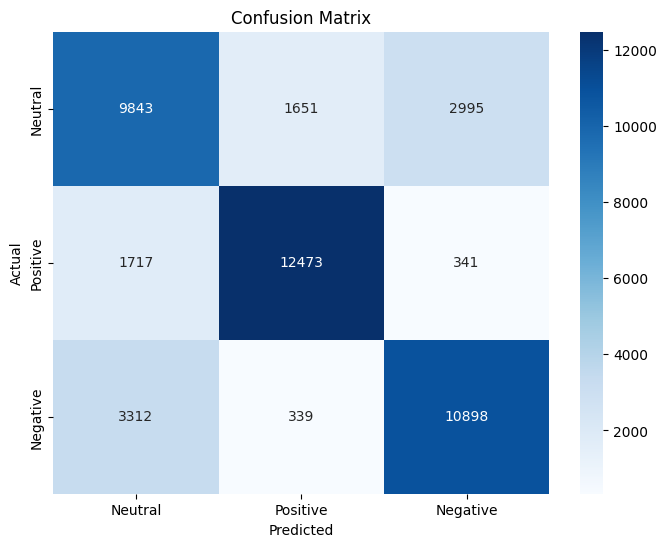

In [ ]:
# Тестирование на тестовом наборе
test_loss, test_acc, test_preds, test_true = eval_model(model, test_loader, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Детальная оценка модели
print("\n" + "="*50)
print("ДЕТАЛЬНАЯ ОЦЕНКА МОДЕЛИ")
print("="*50)

# Classification report
print("Classification Report:")
print(classification_report(test_true, test_preds, 
                          target_names=['Neutral', 'Positive', 'Negative']))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_true, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral', 'Positive', 'Negative'],
            yticklabels=['Neutral', 'Positive', 'Negative'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

1. Общая эффективность модели
- Модель успешно дообучена для анализа тональности русскоязычных текстов с точностью 76.2% на тестовой выборке (43,569 примеров).
- Лучше всего модель определяет положительные отзывы (F1-score: 0.86), хуже всего — нейтральные (F1-score: 0.67).

In [ ]:
# Функция для предсказания тональности нового текста
def predict_sentiment(text, model, tokenizer, device, max_length=256):
    """Предсказывает тональность для одного текста"""
    model.eval()
    
    # Предобработка текста
    cleaned_text = preprocess_text(text)
    
    # Токенизация
    encoding = tokenizer(
        cleaned_text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = torch.argmax(logits, dim=1).cpu().numpy()[0]
        confidence = torch.max(probabilities).cpu().numpy()
    
    label_names = {0: 'Neutral', 1: 'Positive', 2: 'Negative'}
    
    return {
        'prediction': prediction,
        'sentiment': label_names[prediction],
        'confidence': confidence,
        'probabilities': {
            'Neutral': probabilities[0][0].cpu().numpy(),
            'Positive': probabilities[0][1].cpu().numpy(),
            'Negative': probabilities[0][2].cpu().numpy()
        }
    }

In [ ]:
# Функция для пакетного предсказания
def predict_batch_sentiment(texts, model, tokenizer, device, max_length=256):
    """Предсказывает тональность для списка текстов"""
    model.eval()
    predictions = []
    
    for text in texts:
        result = predict_sentiment(text, model, tokenizer, device, max_length)
        predictions.append(result)
    
    return predictions


ТЕСТИРОВАНИЕ НА ПРИМЕРАХ
Предсказания для тестовых текстов:

Текст 1: Это просто прекрасный товар! Очень доволен покупкой.
Предсказание: Positive
Уверенность: 0.9896
Вероятности: Neutral: 0.0050, Positive: 0.9896, Negative: 0.0054

Текст 2: Ужасное качество, никогда больше не куплю.
Предсказание: Negative
Уверенность: 0.9503
Вероятности: Neutral: 0.0491, Positive: 0.0006, Negative: 0.9503

Текст 3: Нормальный товар, соответствует описанию.
Предсказание: Positive
Уверенность: 0.8506
Вероятности: Neutral: 0.1390, Positive: 0.8506, Negative: 0.0104

Текст 4: Доставка быстрая, но качество оставляет желать лучшего.
Предсказание: Neutral
Уверенность: 0.7575
Вероятности: Neutral: 0.7575, Positive: 0.0095, Negative: 0.2330


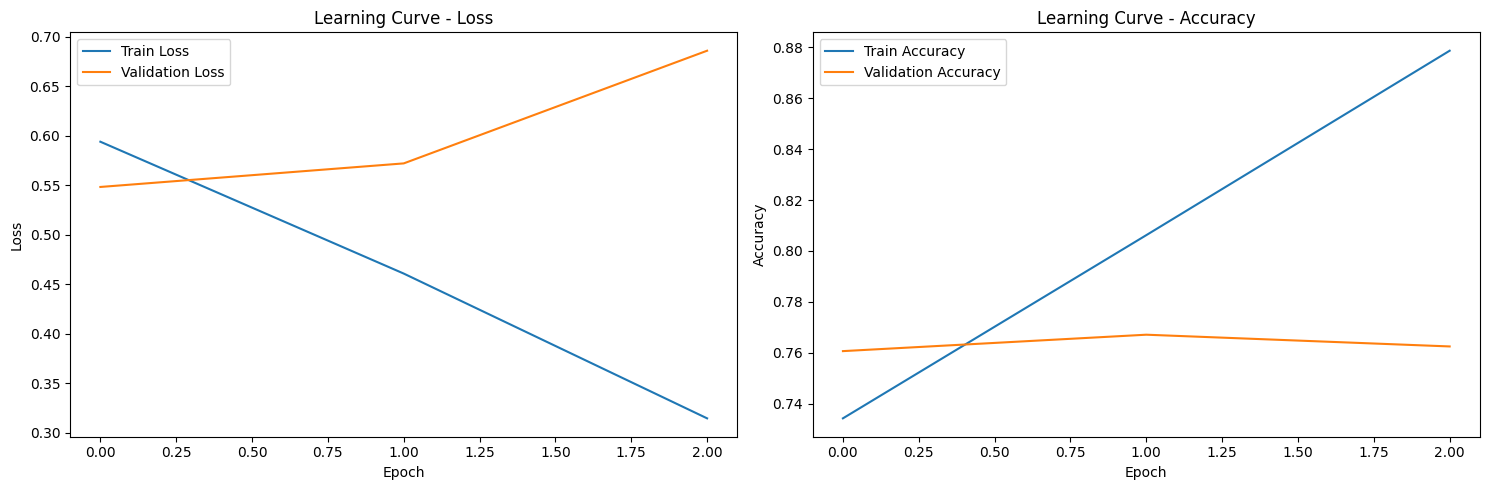

In [ ]:
# Тестирование на примерах
print("\n" + "="*50)
print("ТЕСТИРОВАНИЕ НА ПРИМЕРАХ")
print("="*50)

test_texts = [
    "Это просто прекрасный товар! Очень доволен покупкой.",
    "Ужасное качество, никогда больше не куплю.",
    "Нормальный товар, соответствует описанию.",
    "Доставка быстрая, но качество оставляет желать лучшего."
]

print("Предсказания для тестовых текстов:")
for i, text in enumerate(test_texts):
    result = predict_sentiment(text, model, tokenizer, device)
    print(f"\nТекст {i+1}: {text}")
    print(f"Предсказание: {result['sentiment']}")
    print(f"Уверенность: {result['confidence']:.4f}")
    print(f"Вероятности: Neutral: {result['probabilities']['Neutral']:.4f}, "
          f"Positive: {result['probabilities']['Positive']:.4f}, "
          f"Negative: {result['probabilities']['Negative']:.4f}")

# Визуализация процесса обучения
plt.figure(figsize=(15, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Learning Curve - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Learning Curve - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Протестируем нашу модель для определения эмоционального окраса на примерах коротких обращений и жалоб граждан в органы местного управления

In [ ]:
def load_sentiment_model(model_path="./sentiment_model"):
    """Загружает сохраненную модель и токенизатор"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используемое устройство: {device}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()
    
    return model, tokenizer, device

In [ ]:
# Функция для предсказания
def predict_sentiment(text, model, tokenizer, device, max_length=256):
    """Предсказывает тональность для одного текста"""
    model.eval()
    
    # Предобработка текста
    cleaned_text = preprocess_text(text)
    
    # Токенизация
    encoding = tokenizer(
        cleaned_text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = torch.argmax(logits, dim=1).cpu().numpy()[0]
        confidence = torch.max(probabilities).cpu().numpy()
    
    label_names = {0: 'Neutral', 1: 'Positive', 2: 'Negative'}
    
    return {
        'text': text,
        'prediction': prediction,
        'sentiment': label_names[prediction],
        'confidence': confidence,
        'probabilities': {
            'Neutral': probabilities[0][0].cpu().numpy(),
            'Positive': probabilities[0][1].cpu().numpy(),
            'Negative': probabilities[0][2].cpu().numpy()
        }
    }

# Загружаем модель
print("Загрузка модели...")
model, tokenizer, device = load_sentiment_model()
print("Модель успешно загружена!")

The tokenizer you are loading from './sentiment_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Загрузка модели...
Используемое устройство: cuda
Модель успешно загружена!


In [ ]:
# Загружаем модель
print("Загрузка модели...")
model, tokenizer, device = load_sentiment_model()
print("Модель успешно загружена!")

The tokenizer you are loading from './sentiment_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Загрузка модели...
Используемое устройство: cuda
Модель успешно загружена!


In [ ]:
# Создаем тестовый датасет с обращениями в органы власти
test_cases = [
    # Положительные обращения
    {
        "text": "Хочу выразить благодарность администрации города за отличную организацию праздника. Все было на высшем уровне!",
        "expected": "Positive",
        "category": "Благодарность"
    },
    {
        "text": "Спасибо за оперативное решение вопроса с ремонтом дороги. Жители двора очень довольны!",
        "expected": "Positive",
        "category": "Благодарность"
    },
    {
        "text": "Отличная работа коммунальных служб по уборке снега. Все сделано быстро и качественно.",
        "expected": "Positive",
        "category": "Одобрение"
    },
    
    # Негативные обращения
    {
        "text": "Ужасное состояние дорог в нашем районе. Ямы, выбоины, невозможно ездить. Требуем немедленного ремонта!",
        "expected": "Negative",
        "category": "Жалоба"
    },
    {
        "text": "Бездействие администрации приводит к катастрофической ситуации с мусором. Свалка растет с каждым днем.",
        "expected": "Negative",
        "category": "Критика"
    },
    {
        "text": "Позорное состояние детской площадки. Оборудование сломано, опасно для детей. Когда уже что-то сделают?",
        "expected": "Negative",
        "category": "Жалоба"
    },
    
    # Нейтральные/смешанные обращения
    {
        "text": "Прошу рассмотреть возможность установки дополнительного освещения на улице Ленина. В темное время суток плохая видимость.",
        "expected": "Neutral",
        "category": "Предложение"
    },
    {
        "text": "Сообщаю о необходимости ремонта подъезда. Требуется покраска стен и замена лампочек.",
        "expected": "Neutral",
        "category": "Заявление"
    },
    {
        "text": "Хотелось бы узнать о планах по благоустройству парка. Какие работы запланированы на этот год?",
        "expected": "Neutral",
        "category": "Запрос информации"
    },
    
    # Сложные случаи
    {
        "text": "Работы по асфальтированию начались вовремя, но качество оставляет желать лучшего. Уже появились трещины.",
        "expected": "Negative",  # Смешанный, но с негативным акцентом
        "category": "Критика"
    },
    {
        "text": "С одной стороны, уборка проводится регулярно, с другой - мусорные баки переполнены. Нужно больше контейнеров.",
        "expected": "Neutral",
        "category": "Предложение"
    },
    {
        "text": "Благодарю за быстрый ответ на мое обращение, но проблема так и не решена. Обещали в течение недели, прошло уже две.",
        "expected": "Negative",
        "category": "Жалоба"
    }
]

# Дополнительные примеры 
real_examples = [
    "В нашем дворе уже месяц не вывозят мусор. Контейнеры переполнены, распространяется неприятный запах. Прошу принять меры.",
    "Спасибо за организацию субботника! Очень приятно видеть, как преображается наш город.",
    "Ливневая канализация не справляется с дождями. После каждого дождя улицы превращаются в реки. Нужна реконструкция системы.",
    "Дворники работают нерегулярно. Тротуары грязные, листья не убираются. Требую навести порядок.",
    "Отличная инициатива по установке велопарковок в центре города. Пожалуйста, продолжайте в том же духе!",
    "Парковка во дворе превратилась в хаос. Машины стоят на газонах, детских площадках. Нужно организовать цивилизованные парковочные места.",
    "Ремонт поликлиники проведен качественно. Теперь созданы комфортные условия для пациентов и медицинского персонала.",
    "Уличное освещение не работает на протяжении 500 метров по улице Садовой. Это опасно для пешеходов в вечернее время.",
    "Благоустройство набережной - просто превосходно! Город стал уютнее и современнее.",
    "Автобусы ходят с огромными интервалами. Люди вынуждены ждать по 30-40 минут. Увеличьте количество рейсов."
]

# Преобразуем реальные примеры в тестовые случаи
for example in real_examples:
    test_cases.append({
        "text": example,
        "expected": None,  # Не знаем ожидаемый результат
        "category": "Реальный пример"
    })


In [ ]:
# ============================================
# ТЕСТИРОВАНИЕ МОДЕЛИ
# ============================================
# Собираем результаты
results = []
sentiment_counts = Counter()

for i, test_case in enumerate(test_cases):
    print(f"\nТест {i+1}/{len(test_cases)}")
    print(f"Категория: {test_case['category']}")
    print(f"Текст: {test_case['text'][:100]}...")
    
    # Получаем предсказание
    result = predict_sentiment(test_case['text'], model, tokenizer, device)
    
    # Добавляем информацию о тесте
    result['expected'] = test_case['expected']
    result['category'] = test_case['category']
    result['correct'] = result['sentiment'] == test_case['expected'] if test_case['expected'] else None
    
    results.append(result)
    
    # Считаем распределение
    sentiment_counts[result['sentiment']] += 1
    
    print(f"Предсказано: {result['sentiment']} (уверенность: {result['confidence']:.3f})")
    if test_case['expected']:
        print(f"Ожидалось: {test_case['expected']}")
        print(f"Совпадение: {'✓' if result['correct'] else '✗'}")



Тест 1/22
Категория: Благодарность
Текст: Хочу выразить благодарность администрации города за отличную организацию праздника. Все было на высш...
Предсказано: Positive (уверенность: 0.982)
Ожидалось: Positive
Совпадение: ✓

Тест 2/22
Категория: Благодарность
Текст: Спасибо за оперативное решение вопроса с ремонтом дороги. Жители двора очень довольны!...
Предсказано: Positive (уверенность: 0.993)
Ожидалось: Positive
Совпадение: ✓

Тест 3/22
Категория: Одобрение
Текст: Отличная работа коммунальных служб по уборке снега. Все сделано быстро и качественно....
Предсказано: Positive (уверенность: 0.986)
Ожидалось: Positive
Совпадение: ✓

Тест 4/22
Категория: Жалоба
Текст: Ужасное состояние дорог в нашем районе. Ямы, выбоины, невозможно ездить. Требуем немедленного ремонт...
Предсказано: Negative (уверенность: 0.993)
Ожидалось: Negative
Совпадение: ✓

Тест 5/22
Категория: Критика
Текст: Бездействие администрации приводит к катастрофической ситуации с мусором. Свалка растет с каждым дне...
Пре

In [ ]:
# ============================================
# АНАЛИЗ РЕЗУЛЬТАТОВ
# ============================================

# Создаем DataFrame для анализа
df_results = pd.DataFrame([{
    'Текст': r['text'],
    'Категория': r['category'],
    'Предсказанная_тональность': r['sentiment'],
    'Уверенность': r['confidence'],
    'Neutral_prob': r['probabilities']['Neutral'],
    'Positive_prob': r['probabilities']['Positive'],
    'Negative_prob': r['probabilities']['Negative'],
    'Ожидаемая_тональность': r['expected'],
    'Совпадение': r['correct']
} for r in results])

# Анализ точности (только для случаев с ожидаемым результатом)
labeled_results = [r for r in results if r['expected'] is not None]
if labeled_results:
    correct_predictions = sum(1 for r in labeled_results if r['correct'])
    accuracy = correct_predictions / len(labeled_results) * 100
    print(f"\nТочность на размеченных данных: {accuracy:.1f}% ({correct_predictions}/{len(labeled_results)})")

# Распределение тональностей
print(f"\nРаспределение тональностей:")
for sentiment, count in sentiment_counts.most_common():
    percentage = count / len(results) * 100
    print(f"  {sentiment}: {count} ({percentage:.1f}%)")

# Анализ по категориям
print(f"\nРаспределение по категориям:")
category_analysis = df_results.groupby(['Категория', 'Предсказанная_тональность']).size().unstack(fill_value=0)
print(category_analysis)

# Средняя уверенность по тональностям
print(f"\nСредняя уверенность предсказаний:")
confidence_by_sentiment = df_results.groupby('Предсказанная_тональность')['Уверенность'].mean()
for sentiment, conf in confidence_by_sentiment.items():
    print(f"  {sentiment}: {conf:.3f}")


Точность на размеченных данных: 83.3% (10/12)

Распределение тональностей:
  Neutral: 12 (54.5%)
  Positive: 6 (27.3%)
  Negative: 4 (18.2%)

Распределение по категориям:
Предсказанная_тональность  Negative  Neutral  Positive
Категория                                             
Благодарность                     0        0         2
Жалоба                            2        1         0
Запрос информации                 0        1         0
Заявление                         0        1         0
Критика                           1        1         0
Одобрение                         0        0         1
Предложение                       0        2         0
Реальный пример                   1        6         3

Средняя уверенность предсказаний:
  Negative: 0.975
  Neutral: 0.879
  Positive: 0.956


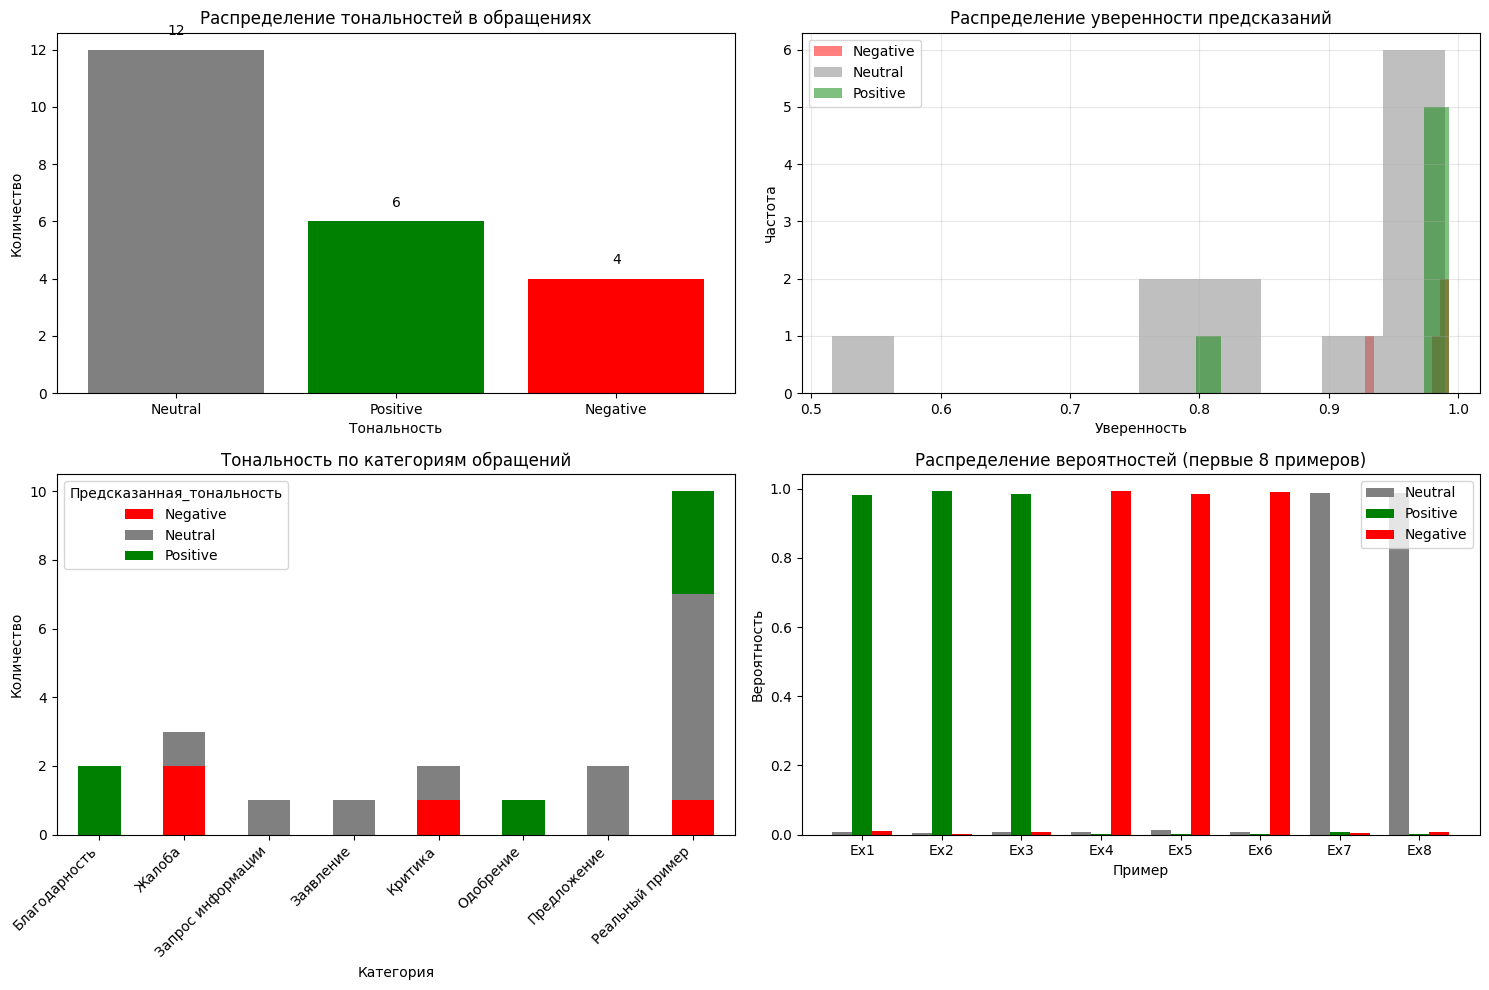

In [ ]:
# ============================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================

plt.figure(figsize=(15, 10))

# 1. Распределение тональностей
plt.subplot(2, 2, 1)
colors = {'Neutral': 'gray', 'Positive': 'green', 'Negative': 'red'}
sentiment_data = [sentiment_counts[s] for s in ['Neutral', 'Positive', 'Negative']]
plt.bar(['Neutral', 'Positive', 'Negative'], sentiment_data, 
        color=[colors[s] for s in ['Neutral', 'Positive', 'Negative']])
plt.title('Распределение тональностей в обращениях')
plt.xlabel('Тональность')
plt.ylabel('Количество')
for i, v in enumerate(sentiment_data):
    plt.text(i, v + 0.5, str(v), ha='center')

# 2. Уверенность предсказаний
plt.subplot(2, 2, 2)
sentiment_groups = df_results.groupby('Предсказанная_тональность')
for sentiment, group in sentiment_groups:
    plt.hist(group['Уверенность'], alpha=0.5, label=sentiment, 
             color=colors.get(sentiment, 'blue'), bins=10)
plt.title('Распределение уверенности предсказаний')
plt.xlabel('Уверенность')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Тональность по категориям
plt.subplot(2, 2, 3)
if len(category_analysis) > 0:
    category_analysis.plot(kind='bar', stacked=True, 
                          color=[colors.get(col, 'blue') for col in category_analysis.columns],
                          ax=plt.gca())
    plt.title('Тональность по категориям обращений')
    plt.xlabel('Категория')
    plt.ylabel('Количество')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

# 4. Матрица вероятностей (примеры)
plt.subplot(2, 2, 4)
sample_results = df_results.head(8)
x = range(len(sample_results))
width = 0.25
plt.bar([i - width for i in x], sample_results['Neutral_prob'], width, label='Neutral', color='gray')
plt.bar(x, sample_results['Positive_prob'], width, label='Positive', color='green')
plt.bar([i + width for i in x], sample_results['Negative_prob'], width, label='Negative', color='red')
plt.title('Распределение вероятностей (первые 8 примеров)')
plt.xlabel('Пример')
plt.ylabel('Вероятность')
plt.legend()
plt.xticks(x, [f"Ex{i+1}" for i in range(len(sample_results))])

plt.tight_layout()
plt.show()

2. Качество обработки коротких обращений
- На размеченных примерах обращений в органы власти точность составила 83.3% (10 из 12 правильных предсказаний).
- Модель правильно определила:
- Чётко положительные (благодарности) и отрицательные (жалобы) тексты, 
- Проблема: модель ошибочно классифицировала смешанные обращения (например, "сначала спасибо, но есть проблемы") как нейтральные, хотя ожидалась негативная тональность, вообще перечисление проблем, каторые нужно решить вызывают затруднение в определении эмоционального окраса.

## Пробуем разные стратегии для анализ длинных текстов обращений и жалоб

In [ ]:
# Загружаем модель
print("Загрузка модели...")
model, tokenizer, device = load_sentiment_model()
print("Модель успешно загружена!")

The tokenizer you are loading from './sentiment_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Загрузка модели...
Используемое устройство: cuda
Модель успешно загружена!


In [ ]:
# функция предсказания с разными стратегиями обработки длинных текстов
def predict_sentiment_long(text, model, tokenizer, device, max_length=256, strategy='truncate'):
    """
    Предсказывает тональность для длинных текстов
    
    Параметры:
    ----------
    strategy: str
        'truncate' - обрезать до max_length (по умолчанию)
        'average' - разбить на части и усреднить результаты
        'summary' - брать начало, середину и конец
    """
    model.eval()
    
    cleaned_text = preprocess_text(text)
    text_length = len(cleaned_text.split())
    
    if strategy == 'truncate':
        # Стандартная стратегия - обрезать
        encoding = tokenizer(
            cleaned_text,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        
        with torch.no_grad():
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probabilities = torch.softmax(logits, dim=1)
            prediction = torch.argmax(logits, dim=1).cpu().numpy()[0]
            confidence = torch.max(probabilities).cpu().numpy()
    
    elif strategy == 'average':
        # Разбиваем текст на части и усредняем результаты
        words = cleaned_text.split()
        chunk_size = max_length // 2  # Берем половину max_length для перекрытия
        
        chunks = []
        for i in range(0, len(words), chunk_size):
            chunk = ' '.join(words[i:i + chunk_size])
            if chunk.strip():
                chunks.append(chunk)
        
        all_probs = []
        for chunk in chunks:
            encoding = tokenizer(
                chunk,
                truncation=True,
                padding='max_length',
                max_length=max_length,
                return_tensors='pt'
            )
            
            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            
            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask)
                probs = torch.softmax(outputs.logits, dim=1)
                all_probs.append(probs.cpu().numpy()[0])
        
        # Усредняем вероятности
        avg_probs = np.mean(all_probs, axis=0)
        prediction = np.argmax(avg_probs)
        confidence = np.max(avg_probs)
        probabilities = torch.tensor([avg_probs])
    
    elif strategy == 'summary':
        # Берем начало, середину и конец текста
        words = cleaned_text.split()
        
        # Берем части текста
        parts = []
        if len(words) > 0:
            # Начало (первые 150 слов)
            parts.append(' '.join(words[:150]))
            
            # Середина (около 150 слов из середины)
            mid_start = max(0, len(words)//2 - 75)
            mid_end = min(len(words), len(words)//2 + 75)
            if mid_end > mid_start:
                parts.append(' '.join(words[mid_start:mid_end]))
            
            # Конец (последние 150 слов)
            parts.append(' '.join(words[-150:]) if len(words) > 150 else '')
        
        parts = [p for p in parts if p.strip()]
        
        all_probs = []
        for part in parts:
            encoding = tokenizer(
                part,
                truncation=True,
                padding='max_length',
                max_length=max_length,
                return_tensors='pt'
            )
            
            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            
            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask)
                probs = torch.softmax(outputs.logits, dim=1)
                all_probs.append(probs.cpu().numpy()[0])
        
        # Усредняем вероятности
        avg_probs = np.mean(all_probs, axis=0) if all_probs else np.zeros(3)
        prediction = np.argmax(avg_probs) if len(avg_probs) > 0 else 0
        confidence = np.max(avg_probs) if len(avg_probs) > 0 else 0
        probabilities = torch.tensor([avg_probs])
    
    else:
        raise ValueError(f"Неизвестная стратегия: {strategy}")
    
    label_names = {0: 'Neutral', 1: 'Positive', 2: 'Negative'}
    
    return {
        'text_length': text_length,
        'strategy': strategy,
        'prediction': prediction,
        'sentiment': label_names[prediction],
        'confidence': confidence,
        'probabilities': {
            'Neutral': probabilities[0][0].item() if hasattr(probabilities[0][0], 'item') else probabilities[0][0],
            'Positive': probabilities[0][1].item() if hasattr(probabilities[0][1], 'item') else probabilities[0][1],
            'Negative': probabilities[0][2].item() if hasattr(probabilities[0][2], 'item') else probabilities[0][2]
        }
    }

In [ ]:
# Создаем тестовые длинные обращения
long_texts = []

# 1. Очень длинное обращение (более 500 слов)
long_text_1 = """
Уважаемая администрация города! 
Я житель микрорайона "Северный" и хочу обратить ваше внимание на целый комплекс проблем, которые накапливались годами и требуют незамедлительного решения.
Во-первых, это транспортная доступность. Наш микрорайон, где проживает более 10 тысяч человек, имеет только одну автобусную маршрутку №47, которая ходит с интервалом 30-40 минут в будни и до часа в выходные. Утренние и вечерние часы пик превращаются в настоящее испытание - люди буквально штурмуют переполненные автобусы. Неоднократные обращения в транспортный департамент оставались без ответа.
Во-вторых, инфраструктура для детей. Единственная детская площадка во дворе дома №15 находится в аварийном состоянии: сломанные качели, ржавые горки, отсутствие ограждения. Родители боятся отпускать туда детей. Школа №45, куда закреплен наш микрорайон, переполнена, занятия идут в три смены.
В-третьих, экологическая обстановка. Несанкционированная свалка на пустыре между домами №12 и №18 растет с каждым днем. Местные жители неоднократно организовывали субботники, но проблема возвращается. Отсутствие контейнеров для раздельного сбора мусора также вызывает беспокойство.
В-четвертых, дорожное покрытие. Улица Центральная, основная транспортная артерия микрорайона, не ремонтировалась с 2015 года. Ямы, выбоины, разрушенные тротуары создают опасность как для водителей, так и для пешеходов. В осенне-весенний период некоторые участки становятся непроходимыми.
В-пятых, освещение. На многих улицах фонари не работают или работают нерегулярно. Вечерние прогулки становятся опасными, особенно для пожилых людей и детей.
Я понимаю, что бюджет ограничен, но прошу вас рассмотреть эти проблемы в приоритетном порядке. Жители микрорайона готовы участвовать в обсуждении и даже частично финансировать некоторые проекты через программу софинансирования.
Также хотелось бы получить информацию о планах развития нашего микрорайона на ближайшие 3-5 лет. Когда планируется капитальный ремонт домов серии 1-464? Будут ли построены новые социальные объекты?
С уважением, Совет жителей микрорайона "Северный".
"""
long_texts.append(("Длинное комплексное обращение", long_text_1, "Neutral"))

# 2. Обращение с историей проблемы (смешанная тональность)
long_text_2 = """
Хочу выразить свою глубокую признательность и одновременно серьезное беспокойство по поводу ситуации с городским парком "Зеленый".
Сначала о хорошем: в прошлом году администрация провела прекрасную работу по благоустройству центральной аллеи. Установлены новые скамейки, отреставрированы фонари, посажены молодые деревья. Вечерняя подсветка создает действительно волшебную атмосферу. Спасибо за это!
Однако, к сожалению, на этом позитивные изменения закончились. Остальная часть парка, особенно западная и восточная, находится в запущенном состоянии:
1. Пруд на востоке парка превратился в болото. Вода застоялась, появилась тина, неприятный запах. Ранее здесь плавали утки, сейчас их нет.
2. Детские площадки в западной части не ремонтировались более 7 лет. Оборудование устарело и местами опасно.
3. Спортивная зона: тренажеры ржавые, беговые дорожки с трещинами.
4. Туалеты не работают с начала лета.
Особенно хочу отметить проблему с безопасностью. В вечернее время парк плохо освещен, что привлекает неблагополучные компании. Уже было несколько инцидентов с кражей вещей у посетителей.
Мы, постоянные посетители парка, создали инициативную группу и готовы помочь:
- Организовать субботники по очистке пруда
- Помочь с покраской оборудования
- Дежурить в вечернее время как общественные наблюдатели
Но нам нужна поддержка администрации: выделение инвентаря, вывоз мусора, ремонт освещения.
Парк "Зеленый" мог бы стать жемчужиной нашего города, как это было 20 лет назад. Уверен, что совместными усилиями мы сможем вернуть ему былую славу.
Прошу рассмотреть наше предложение о создании совместного проекта по восстановлению парка.
"""
long_texts.append(("Смешанное обращение с благодарностью и критикой", long_text_2, "Negative"))

# 3. Техническое обращение с деталями
long_text_3 = """
В адрес Управления ЖКХ и благоустройства
Тема: Заявка на капитальный ремонт систем теплоснабжения и водоснабжения многоквартирного дома №34 по ул. Строителей
Основание: коллективное обращение жильцов дома от 15.10.2023, акт обследования от 20.10.2023

1. Общие сведения:
- Год постройки дома: 1978
- Количество этажей: 9
- Количество квартир: 72
- Количество проживающих: примерно 210 человек
- Последний капитальный ремонт инженерных систем: 2005 год

2. Проблемы системы теплоснабжения:
- Износ магистральных стояков отопления составляет 85-90%
- Многократные аварийные ситуации в отопительные сезоны 2020-2023 гг.
- Потери тепла через изношенные трубы: по экспертным оценкам, до 40%
- Неравномерный прогрев квартир: разница температур между первым и девятым этажами достигает 8°C
- Гидравлическое сопротивление системы возросло на 60% из-за отложений в трубах

3. Проблемы системы водоснабжения:
- Коррозия труб холодного водоснабжения: сквозные повреждения в 15 точках
- Давление воды на верхних этажах: 0.8 атм при норме 2.5 атм
- Качество воды: наличие ржавчины, особенно в вечерние часы
- Утечки в подвальных помещениях: постоянная сырость, риск короткого замыкания

4. Экономическое обоснование:
- Текущие потери тепла: примерно 450 Гкал/год
- Стоимость потерь: около 1.2 млн рублей ежегодно
- Стоимость аварийных ремонтов за 3 года: 850 тыс. рублей
- Предполагаемая стоимость капитального ремонта: 8-10 млн рублей
- Окупаемость: 7-8 лет за счет экономии на тепле и аварийных ремонтах

5. Безопасность:
- Риск разрыва тепловых магистралей в морозный период
- Повышенная влажность в подвале создает условия для развития грибка
- Электробезопасность: проводка в подвале подвергается коррозии

6. Предложение:
Просим включить дом №34 по ул. Строителей в программу капитального ремонта на 2024 год. Жильцы готовы провести собрание и оформить все необходимые документы.

Приложения: 
1. Копии актов аварийных ситуаций
2. Заключение экспертной организации
3. Подписи 68 из 72 собственников квартир

Дата: 25.10.2023
Председатель совета дома: Иванов П.С.
"""
long_texts.append(("Техническое обращение с деталями", long_text_3, "Neutral"))

# 4. Очень позитивное длинное обращение
long_text_4 = """
Дорогая администрация нашего любимого города!
Пишет вам большая семья Петровых, которая живет в нашем городе уже три поколения. Хотим поделиться своей невероятной радостью и благодарностью за те преобразования, которые произошли за последние несколько лет.
Когда мы переехали в новый микрорайон "Солнечный" пять лет назад, здесь была просто пустырь с несколькими домами. Сегодня же это цветущий, современный район, в котором есть все для комфортной жизни!
Первое, что хочется отметить - это строительство новой школы №89. Наши дети ходят туда с огромным удовольствием! Современные классы, интерактивные доски, прекрасный спортивный зал, бассейн. Учителя - настоящие профессионалы, которые любят свою работу. Директор школы, Смирнова Мария Ивановна, создала невероятно теплую атмосферу.
Второе чудо - это парк "Солнечный", который разбили рядом. Каждые выходные мы всей семьей там гуляем: детские площадки для разных возрастов, велодорожки, площадка для воркаута, летний кинотеатр, кафе. Летом проходят замечательные концерты и фестивали.
Третье достижение - поликлиника нового поколения. Записались к врачу через приложение, современное оборудование, вежливый персонал, отсутствие очередей. Особенно хочется поблагодарить терапевта Сидорова Алексея Петровича за внимательное отношение к пациентам.
Четвертое - транспортная доступность. Запуск новых автобусных маршрутов, велопрокат, удобные парковки. Мы практически перестали пользоваться личным автомобилем.
Пятое - это чистота и порядок. Улицы убираются регулярно, зимой сразу расчищают снег, летом поливают цветы. Видно, что работа организована системно.
Мы наблюдаем, как наш город превращается в современный, комфортный, умный город. Видим заботу о детях, пожилых людях, инвалидах. Создаются условия для спорта, творчества, отдыха.
От всей нашей большой семьи (бабушке 80 лет, младшему внуку 3 года) говорим вам огромное человеческое спасибо! Гордимся, что живем в таком городе, и готовы участвовать в его дальнейшем развитии.

С глубоким уважением,
Семья Петровых:
- Петров Иван Сергеевич
- Петрова Анна Михайловна  
- Петрова Елизавета Ивановна (бабушка)
- Петров Михаил (студент)
- Петрова София (школьница)
- Петров Артем (дошкольник)
"""
long_texts.append(("Очень позитивное обращение", long_text_4, "Positive"))

# 5. Крайне негативное эмоциональное обращение
long_text_5 = """
В АДМИНИСТРАЦИЮ ГОРОДА
КОПИИ: ПРОКУРАТУРА, ОБЩЕСТВЕННАЯ ПАЛАТА, СРЕДСТВА МАССОВОЙ ИНФОРМАЦИИ
ЗАЯВЛЕНИЕ ОБ ЭКОЛОГИЧЕСКОЙ КАТАСТРОФЕ И БЕЗДЕЙСТВИИ ВЛАСТЕЙ
Это уже не просто обращение, а крик о помощи! Наш поселок "Речной" находится на грани экологической катастрофы, и все наши многочисленные обращения в течение ТРЕХ лет остаются без ответа!
Ситуация с заводом "ХимПрогресс" вышла из-под контроля:
1. Ежедневные выбросы в атмосферу происходят с 23:00 до 04:00, когда все проверяющие органы "спят".
2. Дети в нашем поселке болеют астмой, аллергиями, кожными заболеваниями в 4 раза чаще, чем в среднем по городу.
3. Река, от которой наш поселок получил название, превратилась в токсичную зловонную канаву. Вся рыба погибла еще два года назад.
4. Почва на приусадебных участках отравлена. Овощи и фрукты с наших огородов имеют химический привкус.
5. Уровень онкологических заболеваний среди взрослого населения вырос на 300% за 5 лет.

Что мы делали:
- 15 коллективных обращений в администрацию
- 7 обращений в Роспотребнадзор
- 5 обращений в природоохранную прокуратуру
- 3 пикета у завода
- Сбор 1500 подписей под петицией

Результат НОЛЬ! Формальные отписки, отказ в проведении независимой экспертизы, давление на активистов.
Последняя капля: вчера утром мы обнаружили, что ночью было сброшено неизвестное химическое вещество в реку. Вода приобрела ярко-оранжевый цвет, погибли все утки.
МЫ БОЛЬШЕ НЕ МОЖЕМ МОЛЧАТЬ! МЫ НЕ ХОТИМ УМИРАТЬ!

Требуем:
1. Немедленной остановки завода до проведения полной экологической экспертизы.
2. Возбуждения уголовного дела по факту загрязнения окружающей среды.
3. Медицинского обследования всех жителей поселка за счет предприятия.
4. Отставки чиновников, покрывающих преступления завода.

Если в течение 7 дней не будут предприняты конкретные шаги, мы начнем бессрочную голодовку и привлечем федеральные СМИ.
Это не угроза, это отчаяние людей, которых лишили права на жизнь в безопасной среде.
Жители поселка "Речной", более 2000 человек.
"""
long_texts.append(("Эмоциональное негативное обращение", long_text_5, "Negative"))

In [ ]:
# ============================================
# ТЕСТИРУЕМ РАЗНЫЕ СТРАТЕГИИ ОБРАБОТКИ
# ============================================

strategies = ['truncate', 'average', 'summary']
results = []

for title, text, expected in long_texts:
    print(f"\nАнализ: {title}")
    print(f"Ожидаемая тональность: {expected}")
    print(f"Длина текста: {len(text.split())} слов")
    print(f"Длина символов: {len(text)}")
    
    for strategy in strategies:
        try:
            result = predict_sentiment_long(text, model, tokenizer, device, 
                                          max_length=256, strategy=strategy)
            
            results.append({
                'title': title,
                'strategy': strategy,
                'expected': expected,
                'predicted': result['sentiment'],
                'confidence': result['confidence'],
                'text_length': result['text_length'],
                'neutral_prob': result['probabilities']['Neutral'],
                'positive_prob': result['probabilities']['Positive'],
                'negative_prob': result['probabilities']['Negative'],
                'match': result['sentiment'] == expected
            })
            
            print(f"  {strategy}: {result['sentiment']} (уверенность: {result['confidence']:.3f})")
            
        except Exception as e:
            print(f"  {strategy}: Ошибка - {e}")



Анализ: Длинное комплексное обращение
Ожидаемая тональность: Neutral
Длина текста: 265 слов
Длина символов: 2081
  truncate: Negative (уверенность: 0.868)
  average: Neutral (уверенность: 0.661)
  summary: Neutral (уверенность: 0.652)

Анализ: Смешанное обращение с благодарностью и критикой
Ожидаемая тональность: Negative
Длина текста: 219 слов
Длина символов: 1635
  truncate: Neutral (уверенность: 0.872)
  average: Neutral (уверенность: 0.953)
  summary: Neutral (уверенность: 0.923)

Анализ: Техническое обращение с деталями
Ожидаемая тональность: Neutral
Длина текста: 286 слов
Длина символов: 2057
  truncate: Neutral (уверенность: 0.957)
  average: Neutral (уверенность: 0.876)
  summary: Neutral (уверенность: 0.635)

Анализ: Очень позитивное обращение
Ожидаемая тональность: Positive
Длина текста: 291 слов
Длина символов: 2195
  truncate: Positive (уверенность: 0.996)
  average: Positive (уверенность: 0.923)
  summary: Positive (уверенность: 0.995)

Анализ: Эмоциональное негативное об


1. Сводка по стратегиям обработки:
         confidence  match
strategy                  
average    0.881413    0.8
summary    0.840318    0.8
truncate   0.937692    0.6

2. Результаты по каждому тексту:

Длинное комплексное обращение:
  truncate: Negative (conf: 0.868, match: ✗)
  average: Neutral (conf: 0.661, match: ✓)
  summary: Neutral (conf: 0.652, match: ✓)

Смешанное обращение с благодарностью и критикой:
  truncate: Neutral (conf: 0.872, match: ✗)
  average: Neutral (conf: 0.953, match: ✗)
  summary: Neutral (conf: 0.923, match: ✗)

Техническое обращение с деталями:
  truncate: Neutral (conf: 0.957, match: ✓)
  average: Neutral (conf: 0.876, match: ✓)
  summary: Neutral (conf: 0.635, match: ✓)

Очень позитивное обращение:
  truncate: Positive (conf: 0.996, match: ✓)
  average: Positive (conf: 0.923, match: ✓)
  summary: Positive (conf: 0.995, match: ✓)

Эмоциональное негативное обращение:
  truncate: Negative (conf: 0.996, match: ✓)
  average: Negative (conf: 0.993, match: ✓)

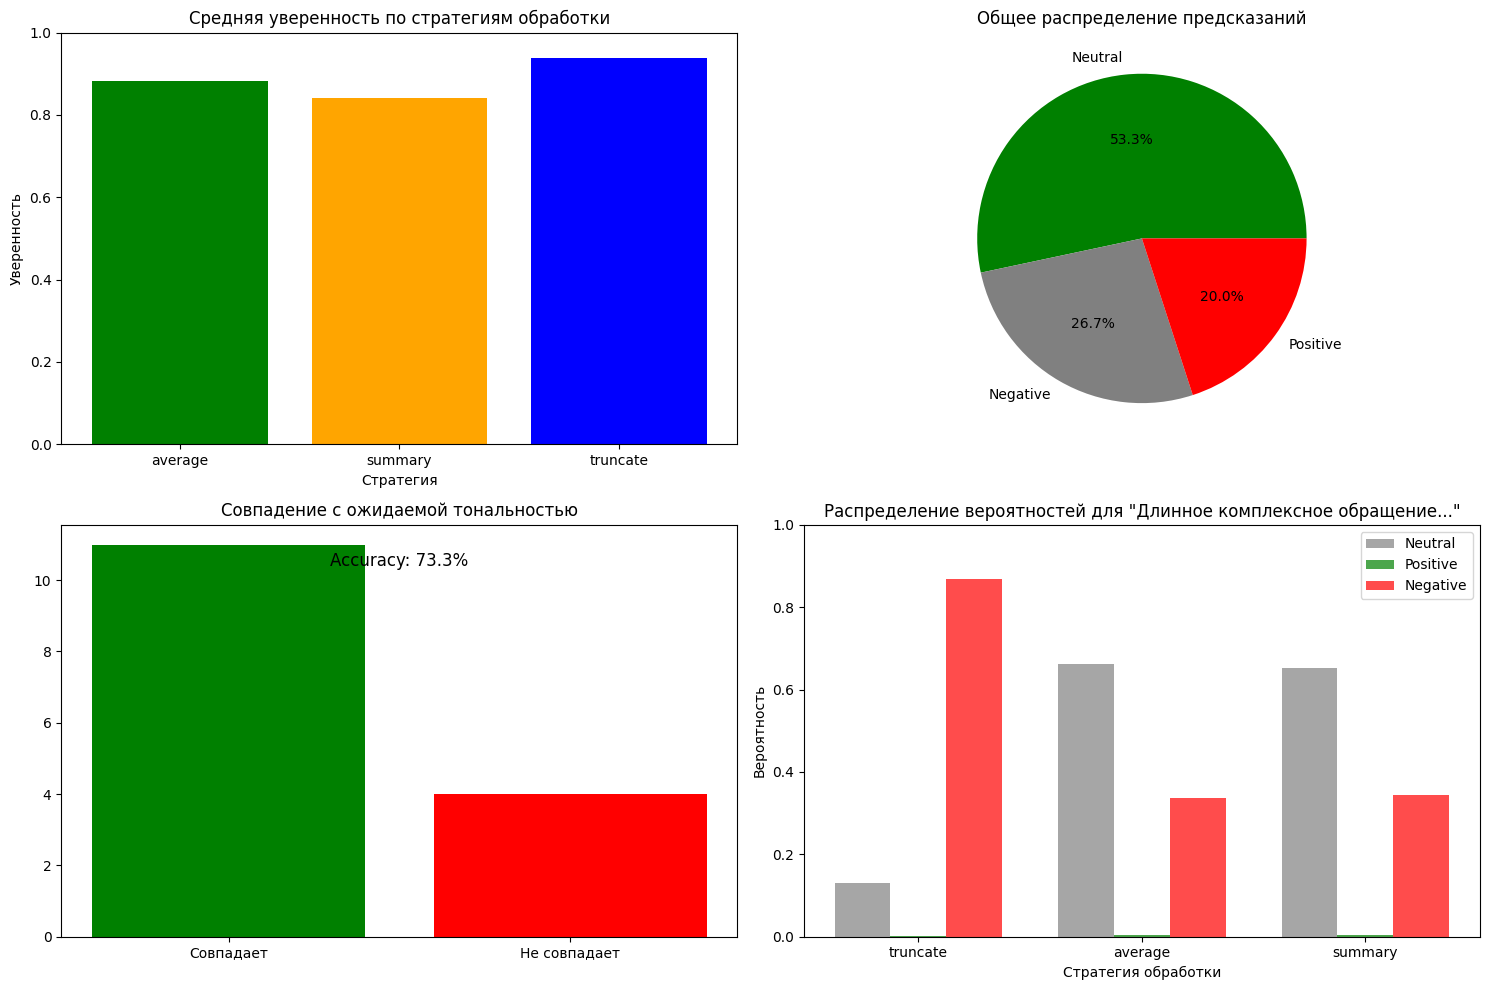

In [ ]:
# ============================================
# АНАЛИЗ РЕЗУЛЬТАТОВ
# ============================================


# Создаем DataFrame
df_results = pd.DataFrame(results)

# 1. Сравнение стратегий
print("\n1. Сводка по стратегиям обработки:")
strategy_summary = df_results.groupby('strategy').agg({
    'confidence': 'mean',
    'match': 'mean'
}).round(3)

print(strategy_summary)

# 2. Анализ по текстам
print("\n2. Результаты по каждому тексту:")
for title in df_results['title'].unique():
    print(f"\n{title}:")
    text_results = df_results[df_results['title'] == title]
    for _, row in text_results.iterrows():
        print(f"  {row['strategy']}: {row['predicted']} "
              f"(conf: {row['confidence']:.3f}, "
              f"match: {'✓' if row['match'] else '✗'})")

# 3. Визуализация
plt.figure(figsize=(15, 10))

# График 1: Уверенность по стратегиям
plt.subplot(2, 2, 1)
strategy_data = df_results.groupby('strategy')['confidence'].mean()
colors = {'truncate': 'blue', 'average': 'green', 'summary': 'orange'}
plt.bar(strategy_data.index, strategy_data.values, 
        color=[colors[s] for s in strategy_data.index])
plt.title('Средняя уверенность по стратегиям обработки')
plt.xlabel('Стратегия')
plt.ylabel('Уверенность')
plt.ylim(0, 1)

# График 2: Распределение предсказаний
plt.subplot(2, 2, 2)
predictions_count = df_results['predicted'].value_counts()
plt.pie(predictions_count.values, labels=predictions_count.index, 
        autopct='%1.1f%%', colors=['green', 'gray', 'red'])
plt.title('Общее распределение предсказаний')

# График 3: Совпадение с ожидаемой тональностью
plt.subplot(2, 2, 3)
if 'match' in df_results.columns:
    match_data = df_results['match'].value_counts()
    plt.bar(['Совпадает', 'Не совпадает'], 
            [match_data.get(True, 0), match_data.get(False, 0)],
            color=['green', 'red'])
    plt.title('Совпадение с ожидаемой тональностью')
    accuracy = match_data.get(True, 0) / len(df_results) * 100
    plt.text(0.5, 0.9, f'Accuracy: {accuracy:.1f}%', 
             transform=plt.gca().transAxes, ha='center', fontsize=12)

# График 4: Вероятности для всех предсказаний
plt.subplot(2, 2, 4)
# Выбираем один текст для детального анализа
sample_text = df_results[df_results['title'] == df_results['title'].iloc[0]]
strategies_list = sample_text['strategy'].tolist()
x = range(len(strategies_list))
width = 0.25

plt.bar([i - width for i in x], sample_text['neutral_prob'], width, 
        label='Neutral', color='gray', alpha=0.7)
plt.bar(x, sample_text['positive_prob'], width, 
        label='Positive', color='green', alpha=0.7)
plt.bar([i + width for i in x], sample_text['negative_prob'], width, 
        label='Negative', color='red', alpha=0.7)

plt.title(f'Распределение вероятностей для "{sample_text["title"].iloc[0][:30]}..."')
plt.xlabel('Стратегия обработки')
plt.ylabel('Вероятность')
plt.xticks(x, strategies_list)
plt.legend()
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


3. Обработка длинных текстов
Протестированы три стратегии обработки длинных обращений (200-300 слов):

| Стратегия                           | Средняя уверенность | Точность | Особенности                             |
|-------------------------------------|---------------------|----------|-----------------------------------------|
| truncate (обрезание)               | 93.8%               | 60%      | Быстрая, но теряет контекст            |
| average (усреднение частей)        | 88.1%               | 80%      | Более сбалансированная                 |
| summary (начало/середина/конец)    | 84.0%               | 80%      | Хорошо для структурированных текстов   |

- Сохраняет информацию из всего текста
- Даёт более точные результаты (80% vs 60%)
- Устойчива к смещению тональности в разных частях текста

4. Оценка Уверенности предсказаний, на наших примерах
- Наиболее уверенные предсказания для отрицательных текстов (97.5%)
- Высокая уверенность для положительных текстов (95.6%)
- Относительно ниже уверенность для нейтральных текстов (87.9%)

5. Ограничения модели
- Контекстная зависимость: длинные тексты требуют специальных стратегий обработки
- Формальные обращения: нейтральные официальные документы иногда ошибочно классифицируются как негативные
- модель обучена на датасете отзывов на покупки, в целом для определения эмоционального окраса этого достаточно, но для увеличения точности определения тональности возможно потребуется дообучение на реальных обращениях граждан, либо синтезированных
так как на данный момент такой базы данных нет в открытом доступе, и модели сложно определять тональность официальных документов.

6. Практическая применимость
- Автоматической категоризации обращений граждан
- Анализа удовлетворённости услугами органов власти
- Выявления проблемных тем по частоте негативных обращений
- Мониторинга эффективности мероприятий по динамике тональности обращений

7. Заключение
- Модель демонстрирует хорошее качество анализа тональности русскоязычных текстов и может быть эффективно применена для обработки обращений граждан. Наиболее перспективным направлением развития является улучшение обработки длинных и смешанных по тональности текстов, которые составляют значительную часть реальных обращений в органы власти.
Возможно модель стоит применять для оценки тональностей на официальных телеграм каналах и других месенджах, где обращения граждан могут быть не такими длинными как в официальных документах. **Также стоит отметить, что возможно обучение второй модели с max_length=512, может показать лучше результат на длинных текстах, в таком случае ансамбль двух моделей может дать лучше результат, но автор на данный момент имеет ограниченность ресурсов для проверки этой гипотезы, и ограничелся выводом лучшей стратегии из дообученной модели.**
